# Notebook 09: IDRiD Dataset Prediction & Comprehensive Analysis

## EfficientNet-B3 Binary & Multi-Class DR Classification — Cross-Dataset Validation

**Dependencies:**
- **Notebook 01** — Preprocessing pipeline (circle crop → Ben Graham → CLAHE → resize 384×384)
- **Notebook 04** — APTOS binary evaluation results (optimal threshold, AUC-ROC, metrics)

**Pipeline:**
1. Load NB04 evaluation results (optimal threshold = 0.4706 via Youden's J)
2. Load IDRiD images (preprocessed via NB01 pipeline, or apply NB01 on raw images)
3. Run binary + multi-class inference using trained EfficientNet-B3 models
4. Evaluate at APTOS optimal threshold and IDRiD-specific threshold
5. Cross-dataset comparison: APTOS 2019 vs IDRiD (domain shift analysis)

In [3]:
# ============================================================================
# 1. Imports & Configuration
# ============================================================================
import os
import sys
import json
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter, OrderedDict

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Image Processing
import cv2
from PIL import Image

# Albumentations (for TTA — matching NB07)
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Scikit-learn Metrics
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, cohen_kappa_score, matthews_corrcoef,
    brier_score_loss, log_loss
)
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports successful")
print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")
print(f"Device:  {'CUDA' if torch.cuda.is_available() else 'CPU'}")


All imports successful
PyTorch: 2.7.1
timm:    1.0.24
Device:  CPU


In [4]:
# ============================================================================
# 2. Configuration — Load NB04 Evaluation Results
# ============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load APTOS Binary Evaluation from NB04 ──
nb04_eval_path = Path('models/aptos_binary_comprehensive_eval.json')
if nb04_eval_path.exists():
    with open(nb04_eval_path) as f:
        aptos_eval = json.load(f)
    APTOS_OPTIMAL_THRESHOLD = aptos_eval.get('optimal_threshold', 0.4706)
    APTOS_AUC = aptos_eval.get('auc_roc', 0.9992)
    APTOS_ACCURACY = aptos_eval.get('accuracy', 0.9906)
    APTOS_SENSITIVITY = aptos_eval.get('sensitivity', 0.9923)
    APTOS_SPECIFICITY = aptos_eval.get('specificity', 0.9889)
    print(f"✓ Loaded NB04 evaluation from: {nb04_eval_path}")
    print(f"  APTOS Optimal Threshold (Youden's J): {APTOS_OPTIMAL_THRESHOLD:.4f}")
    print(f"  APTOS AUC-ROC: {APTOS_AUC:.4f}")
    print(f"  APTOS Accuracy: {APTOS_ACCURACY:.4f}")
    print(f"  APTOS Sensitivity: {APTOS_SENSITIVITY:.4f}")
    print(f"  APTOS Specificity: {APTOS_SPECIFICITY:.4f}")
else:
    APTOS_OPTIMAL_THRESHOLD = 0.4706
    APTOS_AUC = 0.9992
    APTOS_ACCURACY = 0.9906
    APTOS_SENSITIVITY = 0.9923
    APTOS_SPECIFICITY = 0.9889
    print(f"⚠ NB04 eval not found at {nb04_eval_path}, using hardcoded defaults")
    print(f"  Optimal Threshold: {APTOS_OPTIMAL_THRESHOLD}")

CONFIG = {
    'data_root': Path('.'),
    'model_name': 'efficientnet_b3',
    'image_size': 384,
    'dropout_rate': 0.4,
    'binary_num_classes': 1,      # Sigmoid output (NOT 2-class softmax)
    'multiclass_num_classes': 5,
    'binary_threshold': 0.5,
    'optimal_threshold': APTOS_OPTIMAL_THRESHOLD,  # From NB04 evaluation
    'model_dir': Path('models'),
    'idrid_train_dir': Path('IDRiD/Train'),
    'idrid_test_dir': Path('IDRiD/Test'),
    'preprocessed_dir': Path('preprocessed'),
    'output_dir': Path('evaluation/idrid_comprehensive'),
    'figure_dir': Path('evaluation/idrid_comprehensive/figures'),
    # ImageNet normalization (used during training)
    'mean': [0.485, 0.456, 0.406],
    'std':  [0.229, 0.224, 0.225],
    # NB01 Preprocessing parameters
    'ben_graham_sigma': 30,
    'clahe_clip_limit': 2.0,
    'clahe_tile_grid': (8, 8),
    # TTA configuration (matching NB07)
    'tta_times': 8,
    'batch_size': 16,
    'num_workers': 0,
}

# Grade names
GRADE_NAMES = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}
BINARY_NAMES = {0: 'No DR (Healthy)', 1: 'DR (Diseased)'}

# APTOS reference metrics (from NB04) for cross-dataset comparison
APTOS_REFERENCE = {
    'optimal_threshold': APTOS_OPTIMAL_THRESHOLD,
    'auc_roc': APTOS_AUC,
    'accuracy': APTOS_ACCURACY,
    'sensitivity': APTOS_SENSITIVITY,
    'specificity': APTOS_SPECIFICITY,
}

# Create output directories
CONFIG['output_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['figure_dir'].mkdir(parents=True, exist_ok=True)

print("\nConfiguration set")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")
print(f"\nAPTOS Reference (from NB04):")
for k, v in APTOS_REFERENCE.items():
    print(f"   {k}: {v}")

✓ Loaded NB04 evaluation from: models/aptos_binary_comprehensive_eval.json
  APTOS Optimal Threshold (Youden's J): 0.4706
  APTOS AUC-ROC: 0.9992
  APTOS Accuracy: 0.9906
  APTOS Sensitivity: 0.9923
  APTOS Specificity: 0.9889

Configuration set
   data_root: .
   model_name: efficientnet_b3
   image_size: 384
   dropout_rate: 0.4
   binary_num_classes: 1
   multiclass_num_classes: 5
   binary_threshold: 0.5
   optimal_threshold: 0.4706455171108246
   model_dir: models
   idrid_train_dir: IDRiD/Train
   idrid_test_dir: IDRiD/Test
   preprocessed_dir: preprocessed
   output_dir: evaluation/idrid_comprehensive
   figure_dir: evaluation/idrid_comprehensive/figures
   mean: [0.485, 0.456, 0.406]
   std: [0.229, 0.224, 0.225]
   ben_graham_sigma: 30
   clahe_clip_limit: 2.0
   clahe_tile_grid: (8, 8)
   tta_times: 8
   batch_size: 16
   num_workers: 0

APTOS Reference (from NB04):
   optimal_threshold: 0.4706455171108246
   auc_roc: 0.9992
   accuracy: 0.9906
   sensitivity: 0.9923
   speci

## 2. Load IDRiD Dataset Annotations

Load the IDRiD train and test annotations, merge with preprocessed image paths from the merged dataset.


In [6]:
# ============================================================================
# 3. Load IDRiD Annotations
# ============================================================================

# Load IDRiD annotations
train_ann = pd.read_csv(CONFIG['idrid_train_dir'] / 'annotations.csv')
test_ann = pd.read_csv(CONFIG['idrid_test_dir'] / 'annotations.csv')

print(f"IDRiD Train annotations: {len(train_ann)}")
print(f"IDRiD Test annotations:  {len(test_ann)}")
print(f"\nTrain columns: {list(train_ann.columns)}")
print(f"\nTrain DR grade distribution:")
print(train_ann['Retinopathy grade'].value_counts().sort_index())
print(f"\nTest DR grade distribution:")
print(test_ann['Retinopathy grade'].value_counts().sort_index())


IDRiD Train annotations: 1239
IDRiD Test annotations:  309

Train columns: ['Image name', 'Retinopathy grade', 'Risk of macular edema', 'class', 'caption']

Train DR grade distribution:
Retinopathy grade
0    402
1     60
2    408
3    222
4    147
Name: count, dtype: int64

Test DR grade distribution:
Retinopathy grade
0    102
1     15
2     96
3     57
4     39
Name: count, dtype: int64


In [7]:
# ============================================================================
# 4. Prepare IDRiD DataFrames with Preprocessed + Raw Paths
# ============================================================================

# Load the merged preprocessed labels
merged_df = pd.read_csv('merged_labels_preprocessed.csv')
idrid_merged = merged_df[merged_df['original_dataset'] == 'idrid'].copy()

print(f"IDRiD images in merged dataset: {len(idrid_merged)}")

# Separate train and test based on image_id prefix
idrid_train_merged = idrid_merged[idrid_merged['image_id'].str.contains('train')].copy()
idrid_test_merged = idrid_merged[idrid_merged['image_id'].str.contains('test')].copy()

print(f"IDRiD Train (merged): {len(idrid_train_merged)}")
print(f"IDRiD Test  (merged): {len(idrid_test_merged)}")

# Create binary label (0: No DR, 1: DR)
for df in [idrid_train_merged, idrid_test_merged]:
    df['binary_label'] = (df['dr_grade'] > 0).astype(int)

# ── Add raw image paths for NB01 preprocessing fallback ──
def add_raw_paths(df, split_dir):
    """Add raw image paths from IDRiD original directories."""
    raw_paths = []
    for _, row in df.iterrows():
        # Extract original filename from image_id (e.g., 'idrid_test_IDRiD_001' → 'IDRiD_001.jpg')
        img_name = row['image_id'].replace('idrid_test_', '').replace('idrid_train_', '')
        raw_path = split_dir / 'images' / f'{img_name}.jpg'
        raw_paths.append(str(raw_path) if raw_path.exists() else None)
    df['raw_path'] = raw_paths
    found = sum(1 for p in raw_paths if p is not None)
    print(f"  Raw paths found: {found}/{len(df)}")
    return df

print("\nAdding raw IDRiD image paths (for NB01 preprocessing fallback):")
print("Train:")
idrid_train_merged = add_raw_paths(idrid_train_merged, CONFIG['idrid_train_dir'])
print("Test:")
idrid_test_merged = add_raw_paths(idrid_test_merged, CONFIG['idrid_test_dir'])

# Also check which IDRiD images ended up in our model train/val splits
splits_train = pd.read_csv('splits/train_split.csv')
splits_val = pd.read_csv('splits/val_split.csv')
splits_test = pd.read_csv('splits/test_split.csv')

idrid_in_train = splits_train[splits_train['image_id'].str.startswith('idrid')]
idrid_in_val = splits_val[splits_val['image_id'].str.startswith('idrid')]
idrid_in_test = splits_test[splits_test['image_id'].str.startswith('idrid')]

print(f"\nIDRiD images in model splits:")
print(f"  Training set: {len(idrid_in_train)}")
print(f"  Validation:   {len(idrid_in_val)}")
print(f"  Test set:     {len(idrid_in_test)}")

# Check preprocessed path availability
for name, df in [('Train', idrid_train_merged), ('Test', idrid_test_merged)]:
    if 'preprocessed_path' in df.columns:
        exists = df['preprocessed_path'].apply(lambda p: Path(p).exists() if pd.notna(p) else False).sum()
        print(f"\n{name} preprocessed images found: {exists}/{len(df)}")
    else:
        print(f"\n{name}: No 'preprocessed_path' column — will use NB01 raw preprocessing")

IDRiD images in merged dataset: 1530
IDRiD Train (merged): 1224
IDRiD Test  (merged): 306

Adding raw IDRiD image paths (for NB01 preprocessing fallback):
Train:
  Raw paths found: 1224/1224
Test:
  Raw paths found: 306/306

IDRiD images in model splits:
  Training set: 1080
  Validation:   230
  Test set:     220

Train preprocessed images found: 1224/1224

Test preprocessed images found: 306/306


## 3. Dataset Overview & Distribution Analysis

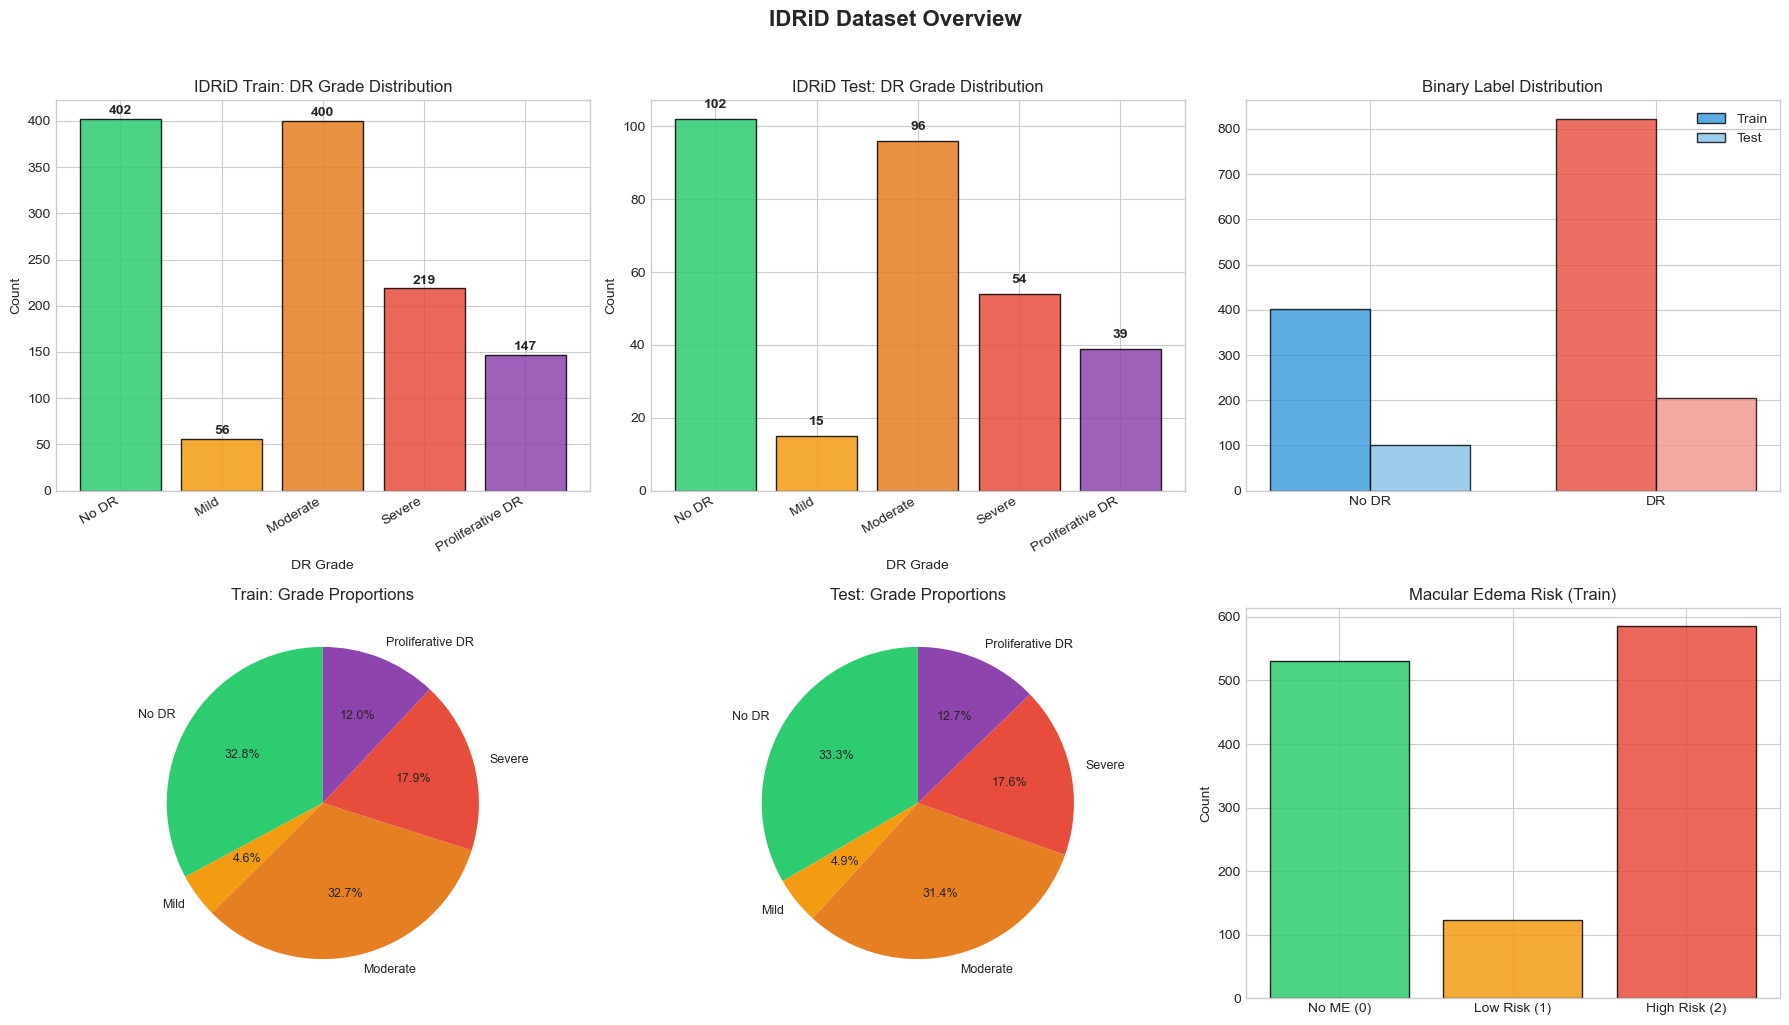

Dataset overview saved


In [9]:
# ============================================================================
# 5. Dataset Overview Visualization
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IDRiD Dataset Overview', fontsize=16, fontweight='bold', y=1.02)

# 5a. Train DR grade distribution
grade_counts_train = idrid_train_merged['dr_grade'].value_counts().sort_index()
colors_grade = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
axes[0, 0].bar(grade_counts_train.index, grade_counts_train.values, color=colors_grade, edgecolor='black', alpha=0.85)
axes[0, 0].set_xlabel('DR Grade')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('IDRiD Train: DR Grade Distribution')
axes[0, 0].set_xticks(range(5))
axes[0, 0].set_xticklabels([GRADE_NAMES[i] for i in range(5)], rotation=30, ha='right')
for i, v in enumerate(grade_counts_train.values):
    axes[0, 0].text(grade_counts_train.index[i], v + 5, str(v), ha='center', fontweight='bold')

# 5b. Test DR grade distribution
grade_counts_test = idrid_test_merged['dr_grade'].value_counts().sort_index()
axes[0, 1].bar(grade_counts_test.index, grade_counts_test.values, color=colors_grade, edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('DR Grade')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('IDRiD Test: DR Grade Distribution')
axes[0, 1].set_xticks(range(5))
axes[0, 1].set_xticklabels([GRADE_NAMES[i] for i in range(5)], rotation=30, ha='right')
for i, v in enumerate(grade_counts_test.values):
    axes[0, 1].text(grade_counts_test.index[i], v + 3, str(v), ha='center', fontweight='bold')

# 5c. Binary distribution comparison
binary_train = idrid_train_merged['binary_label'].value_counts().sort_index()
binary_test = idrid_test_merged['binary_label'].value_counts().sort_index()
x = np.arange(2)
w = 0.35
axes[0, 2].bar(x - w/2, binary_train.values, w, label='Train', color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 2].bar(x + w/2, binary_test.values, w, label='Test', color=['#85c1e9', '#f1948a'], alpha=0.8, edgecolor='black')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(['No DR', 'DR'])
axes[0, 2].set_title('Binary Label Distribution')
axes[0, 2].legend()

# 5d. Train grade proportions (pie)
axes[1, 0].pie(grade_counts_train.values, labels=[GRADE_NAMES[i] for i in grade_counts_train.index],
               colors=colors_grade, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
axes[1, 0].set_title('Train: Grade Proportions')

# 5e. Test grade proportions (pie)
axes[1, 1].pie(grade_counts_test.values, labels=[GRADE_NAMES[i] for i in grade_counts_test.index],
               colors=colors_grade, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
axes[1, 1].set_title('Test: Grade Proportions')

# 5f. Macular Edema distribution (from original annotations)
if 'Risk of macular edema' in train_ann.columns:
    me_counts = train_ann['Risk of macular edema'].value_counts().sort_index()
    me_labels = {0: 'No ME (0)', 1: 'Low Risk (1)', 2: 'High Risk (2)'}
    axes[1, 2].bar([me_labels.get(i, str(i)) for i in me_counts.index], me_counts.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', alpha=0.85)
    axes[1, 2].set_title('Macular Edema Risk (Train)')
    axes[1, 2].set_ylabel('Count')
else:
    axes[1, 2].text(0.5, 0.5, 'ME data not available', ha='center', va='center', transform=axes[1, 2].transAxes)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset overview saved")


## 4. Model Architecture & Loading

**Important architectural details:**
- Binary model: `timm.create_model('efficientnet_b3')` with classifier replaced by `Dropout(0.4) + Linear(1536, 1)` → sigmoid output
- Multi-class model: `timm.create_model('efficientnet_b3')` with classifier replaced by `Dropout(0.4) + Linear(1536, 5)` → softmax output
- Both use checkpoint format with keys: `model_state_dict`, `config`, `best_val_auc`/`best_val_qwk`


In [11]:
# ============================================================================
# 6. Load Trained Models (Correct Architecture)
# ============================================================================

def load_binary_model(ckpt_path, model_name='efficientnet_b3', device='cpu'):
    """
    Load binary model: timm EfficientNet-B3 with replaced classifier.
    Output: 1 logit (sigmoid for probability).
    """
    model = timm.create_model(model_name, pretrained=False)
    n_features = model.classifier.in_features  # 1536
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(n_features, 1),
    )
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)
    model.eval()
    return model, ckpt


def load_multiclass_model(ckpt_path, model_name='efficientnet_b3', num_classes=5, device='cpu'):
    """
    Load multi-class model: timm EfficientNet-B3 with replaced classifier.
    Output: 5 logits (softmax for class probabilities).
    """
    model = timm.create_model(model_name, pretrained=False)
    n_features = model.classifier.in_features  # 1536
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(n_features, num_classes),
    )
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)
    model.eval()
    return model, ckpt


# ── Load Binary Model ──
binary_ckpt_path = CONFIG['model_dir'] / 'best_binary_model.pth'
binary_model, binary_ckpt = load_binary_model(binary_ckpt_path, CONFIG['model_name'], DEVICE)

print(f"Binary Model loaded from: {binary_ckpt_path}")
print(f"  Architecture:  {CONFIG['model_name']} + Dropout(0.4) + Linear(1536, 1)")
print(f"  Best val AUC:  {binary_ckpt.get('best_val_auc', 'N/A'):.4f}")
print(f"  Num classes:   {binary_ckpt.get('num_classes', 'N/A')} (sigmoid output)")
print(f"  Parameters:    {sum(p.numel() for p in binary_model.parameters()):,}")

print()

# ── Load Multi-Class Model ──
multi_ckpt_path = CONFIG['model_dir'] / 'best_multiclass_model.pth'
multiclass_model, multi_ckpt = load_multiclass_model(multi_ckpt_path, CONFIG['model_name'], 5, DEVICE)

print(f"Multi-Class Model loaded from: {multi_ckpt_path}")
print(f"  Architecture:  {CONFIG['model_name']} + Dropout(0.4) + Linear(1536, 5)")
print(f"  Best val QWK:  {multi_ckpt.get('best_val_qwk', 'N/A'):.4f}")
print(f"  Num classes:   {multi_ckpt.get('num_classes', 'N/A')} (softmax output)")
print(f"  Parameters:    {sum(p.numel() for p in multiclass_model.parameters()):,}")

print(f"\nDevice: {DEVICE}")


Binary Model loaded from: models/best_binary_model.pth
  Architecture:  efficientnet_b3 + Dropout(0.4) + Linear(1536, 1)
  Best val AUC:  0.9958
  Num classes:   1 (sigmoid output)
  Parameters:    10,697,769

Multi-Class Model loaded from: models/best_multiclass_model.pth
  Architecture:  efficientnet_b3 + Dropout(0.4) + Linear(1536, 5)
  Best val QWK:  0.8636
  Num classes:   5 (softmax output)
  Parameters:    10,703,917

Device: cpu


In [12]:
# ============================================================================
# 7. Verify Models with Test Forward Pass
# ============================================================================

# Create a dummy input to verify architecture
dummy_input = torch.randn(1, 3, CONFIG['image_size'], CONFIG['image_size']).to(DEVICE)

with torch.no_grad():
    # Binary model test
    binary_logit = binary_model(dummy_input)
    binary_prob = torch.sigmoid(binary_logit)
    print(f"Binary model output shape:  {binary_logit.shape}  (expected: [1, 1])")
    print(f"Binary sigmoid probability: {binary_prob.item():.4f}")

    # Multi-class model test
    multi_logit = multiclass_model(dummy_input)
    multi_prob = F.softmax(multi_logit, dim=1)
    print(f"\nMulti-class output shape:   {multi_logit.shape}  (expected: [1, 5])")
    print(f"Multi-class probabilities:  {multi_prob.cpu().numpy().round(4)}")
    print(f"Predicted grade:            {multi_logit.argmax(dim=1).item()}")

print("\nBoth models verified successfully!")


Binary model output shape:  torch.Size([1, 1])  (expected: [1, 1])
Binary sigmoid probability: 0.4261

Multi-class output shape:   torch.Size([1, 5])  (expected: [1, 5])
Multi-class probabilities:  [[0.2175 0.1852 0.0894 0.1865 0.3213]]
Predicted grade:            4

Both models verified successfully!


## 5. NB01 Preprocessing Pipeline & Inference Functions

Preprocessing pipeline from **Notebook 01** applied to IDRiD images:
1. **Circle Crop** — Detect fundus region, remove black borders
2. **Ben Graham Enhancement** — `cv2.addWeighted(img, 4, blur, -4, 128)` with σ=30
3. **CLAHE** — Adaptive histogram equalization on L channel (clip=2.0, tile=8×8)
4. **Resize** — Scale to 384×384 preserving aspect ratio with black padding

Images are preprocessed via the merged pipeline in NB01 and stored in `preprocessed/` directory.
The inference functions below load these preprocessed images, apply ImageNet normalization, and run predictions.

In [14]:
# ============================================================================
# 8. NB01 Preprocessing Functions + TTA Inference Pipeline
# ============================================================================

# ── NB01 Preprocessing Functions (4-stage pipeline) ──

def circle_crop(img):
    """Stage 1: Detect circular fundus region and crop black borders."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    pad = 5
    x = max(0, x - pad)
    y = max(0, y - pad)
    w = min(img.shape[1] - x, w + 2 * pad)
    h = min(img.shape[0] - y, h + 2 * pad)
    return img[y:y+h, x:x+w]


def ben_graham_preprocess(img, sigma=30):
    """Stage 2: Ben Graham — cv2.addWeighted(img, 4, blur, -4, 128)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)


def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Stage 3: CLAHE on L channel of LAB color space."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_clahe, a, b]), cv2.COLOR_LAB2BGR)


def resize_with_padding(img, target_size=384):
    """Stage 4: Resize preserving aspect ratio with black padding."""
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    y_off = (target_size - new_h) // 2
    x_off = (target_size - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas


def preprocess_fundus_image(img_path, sigma=30, clip_limit=2.0, target_size=384):
    """Full NB01 4-stage pipeline: raw image path -> preprocessed 384x384 BGR."""
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Could not read: {img_path}")
    img = circle_crop(img)
    img = ben_graham_preprocess(img, sigma=sigma)
    img = apply_clahe(img, clip_limit=clip_limit)
    img = resize_with_padding(img, target_size=target_size)
    return img


# ── Albumentations Transforms (matching NB07) ──

val_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2(),
])

tta_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2(),
])


# ── PyTorch Dataset ──

class IDRiDDataset(Dataset):
    """Loads preprocessed images (or applies NB01 on raw). Returns (tensor, label, idx)."""
    def __init__(self, df, transform, config):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.config = config

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = None

        # Try preprocessed path first
        if 'preprocessed_path' in row and pd.notna(row.get('preprocessed_path')):
            p = Path(row['preprocessed_path'])
            if p.exists():
                img = cv2.imread(str(p))

        # Fallback: raw image + NB01 preprocessing
        if img is None and 'raw_path' in row and pd.notna(row.get('raw_path')):
            img = preprocess_fundus_image(
                row['raw_path'],
                sigma=self.config.get('ben_graham_sigma', 30),
                clip_limit=self.config.get('clahe_clip_limit', 2.0),
                target_size=self.config['image_size'],
            )

        if img is None:
            raise FileNotFoundError(f"No image for {row.get('image_id', idx)}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        label = torch.tensor(row.get('binary_label', int(row.get('dr_grade', 0) > 0)),
                             dtype=torch.float32)
        return img, label, idx


# ── Inference: No TTA ──

@torch.no_grad()
def predict_no_tta(model, df, config, device, is_binary=True):
    """Single-pass inference (no TTA). Returns numpy array of probabilities."""
    ds = IDRiDDataset(df, val_transform, config)
    dl = DataLoader(ds, batch_size=config['batch_size'], shuffle=False,
                    num_workers=config['num_workers'])
    all_logits = []
    for imgs, _, _ in dl:
        logits = model(imgs.to(device))
        if is_binary:
            logits = logits.squeeze(-1) if logits.dim() > 1 else logits
        all_logits.append(logits.cpu())
    logits = torch.cat(all_logits).numpy()
    if is_binary:
        return 1 / (1 + np.exp(-logits))
    else:
        exp_l = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp_l / exp_l.sum(axis=1, keepdims=True)


# ── Inference: TTA (matching NB07 strategy) ──

@torch.no_grad()
def predict_with_tta(model, df, config, device, n_tta=8, is_binary=True):
    """
    Test-Time Augmentation: n_tta passes (1 clean + n_tta-1 augmented).
    Averages probabilities across all passes.
    Augmentations: HorizontalFlip, VerticalFlip, RandomRotate90 (matching NB07).
    """
    all_probs = []
    for i in range(n_tta):
        tfm = val_transform if i == 0 else tta_transform
        ds = IDRiDDataset(df, tfm, config)
        dl = DataLoader(ds, batch_size=config['batch_size'], shuffle=False,
                        num_workers=config['num_workers'])
        logits_list = []
        for imgs, _, _ in dl:
            logits = model(imgs.to(device))
            if is_binary:
                logits = logits.squeeze(-1) if logits.dim() > 1 else logits
            logits_list.append(logits.cpu())
        logits = torch.cat(logits_list).numpy()

        if is_binary:
            probs = 1 / (1 + np.exp(-logits))
        else:
            exp_l = np.exp(logits - logits.max(axis=1, keepdims=True))
            probs = exp_l / exp_l.sum(axis=1, keepdims=True)
        all_probs.append(probs)

        if (i + 1) % 4 == 0:
            print(f"    TTA pass {i+1}/{n_tta} done")

    return np.mean(all_probs, axis=0)


print("NB01 preprocessing functions loaded:")
print("  circle_crop -> ben_graham(sigma=30) -> apply_clahe(clip=2.0) -> resize(384)")
print()
print("TTA configuration (matching NB07):")
print(f"  TTA passes: {CONFIG['tta_times']} (1 clean + {CONFIG['tta_times']-1} augmented)")
print("  Augmentations: HorizontalFlip, VerticalFlip, RandomRotate90")
print("  Normalization: ImageNet mean/std")
print()
print("Inference functions: predict_no_tta() and predict_with_tta()")


NB01 preprocessing functions loaded:
  circle_crop -> ben_graham(sigma=30) -> apply_clahe(clip=2.0) -> resize(384)

TTA configuration (matching NB07):
  TTA passes: 8 (1 clean + 7 augmented)
  Augmentations: HorizontalFlip, VerticalFlip, RandomRotate90
  Normalization: ImageNet mean/std

Inference functions: predict_no_tta() and predict_with_tta()


In [ ]:
# ============================================================================
# 9. Run Predictions on IDRiD — No TTA vs 8x TTA
# ============================================================================

y_test = idrid_test_merged['binary_label'].values if 'binary_label' in idrid_test_merged.columns \
    else (idrid_test_merged['dr_grade'] > 0).astype(int).values

# ==============================================================
# A) Binary Model — No TTA (baseline)
# ==============================================================
print("=" * 70)
print("Binary Model — No TTA (baseline)")
print("=" * 70)
t0 = time.time()
binary_probs_noTTA = predict_no_tta(binary_model, idrid_test_merged, CONFIG, DEVICE, is_binary=True)
print(f"  Done in {time.time()-t0:.1f}s — {len(binary_probs_noTTA)} images")

# ==============================================================
# B) Binary Model — 8x TTA
# ==============================================================
print(f"\nBinary Model — {CONFIG['tta_times']}x TTA")
print("=" * 70)
t0 = time.time()
binary_probs_TTA = predict_with_tta(
    binary_model, idrid_test_merged, CONFIG, DEVICE,
    n_tta=CONFIG['tta_times'], is_binary=True
)
print(f"  Done in {time.time()-t0:.1f}s — {len(binary_probs_TTA)} images")

# ==============================================================
# C) Multi-class Model — No TTA
# ==============================================================
print(f"\nMulti-class Model — No TTA")
print("=" * 70)
t0 = time.time()
multi_probs_noTTA = predict_no_tta(multiclass_model, idrid_test_merged, CONFIG, DEVICE, is_binary=False)
print(f"  Done in {time.time()-t0:.1f}s")

# ==============================================================
# D) Multi-class Model — 8x TTA
# ==============================================================
print(f"\nMulti-class Model — {CONFIG['tta_times']}x TTA")
print("=" * 70)
t0 = time.time()
multi_probs_TTA = predict_with_tta(
    multiclass_model, idrid_test_merged, CONFIG, DEVICE,
    n_tta=CONFIG['tta_times'], is_binary=False
)
print(f"  Done in {time.time()-t0:.1f}s")

# ==============================================================
# Build results DataFrame (TTA as primary predictions)
# ==============================================================
test_pred = idrid_test_merged.copy()
test_pred['binary_prob_noTTA'] = binary_probs_noTTA
test_pred['binary_prob'] = binary_probs_TTA          # TTA is primary
test_pred['binary_pred_default'] = (binary_probs_TTA >= 0.5).astype(int)
test_pred['binary_pred_optimal'] = (binary_probs_TTA >= CONFIG['optimal_threshold']).astype(int)

# Multi-class
test_pred['multi_pred_noTTA'] = multi_probs_noTTA.argmax(axis=1)
test_pred['multi_pred'] = multi_probs_TTA.argmax(axis=1)
for g in range(5):
    test_pred[f'prob_grade_{g}'] = multi_probs_TTA[:, g]

# Quick comparison: No TTA vs TTA
auc_noTTA = roc_auc_score(y_test, binary_probs_noTTA)
auc_TTA = roc_auc_score(y_test, binary_probs_TTA)
print(f"\n{'='*70}")
print(f"TTA Impact Summary (IDRiD Test, n={len(y_test)})")
print(f"{'='*70}")
print(f"  Binary AUC-ROC (No TTA):  {auc_noTTA:.4f}")
print(f"  Binary AUC-ROC (8x TTA):  {auc_TTA:.4f}")
print(f"  Improvement:               {auc_TTA - auc_noTTA:+.4f}")
print(f"\n  P(DR) range (No TTA): [{binary_probs_noTTA.min():.6f}, {binary_probs_noTTA.max():.6f}]")
print(f"  P(DR) range (TTA):    [{binary_probs_TTA.min():.6f}, {binary_probs_TTA.max():.6f}]")
print(f"  Mean diff |noTTA - TTA|: {np.abs(binary_probs_noTTA - binary_probs_TTA).mean():.6f}")

# Save predictions
test_pred.to_csv(CONFIG['output_dir'] / 'idrid_test_predictions.csv', index=False)
print(f"\nPredictions saved to {CONFIG['output_dir'] / 'idrid_test_predictions.csv'}")

# ==============================================================
# Also run on TRAIN set with TTA
# ==============================================================
print(f"\n{'='*70}")
print(f"Running predictions on IDRiD TRAIN set ({CONFIG['tta_times']}x TTA)...")
print(f"{'='*70}")
t0 = time.time()
train_binary_probs_TTA = predict_with_tta(
    binary_model, idrid_train_merged, CONFIG, DEVICE,
    n_tta=CONFIG['tta_times'], is_binary=True
)
train_multi_probs_TTA = predict_with_tta(
    multiclass_model, idrid_train_merged, CONFIG, DEVICE,
    n_tta=CONFIG['tta_times'], is_binary=False
)
print(f"  Done in {time.time()-t0:.1f}s")

train_pred = idrid_train_merged.copy()
train_pred['binary_prob'] = train_binary_probs_TTA
train_pred['binary_pred_default'] = (train_binary_probs_TTA >= 0.5).astype(int)
train_pred['binary_pred_optimal'] = (train_binary_probs_TTA >= CONFIG['optimal_threshold']).astype(int)
train_pred['multi_pred'] = train_multi_probs_TTA.argmax(axis=1)
for g in range(5):
    train_pred[f'prob_grade_{g}'] = train_multi_probs_TTA[:, g]

train_pred.to_csv(CONFIG['output_dir'] / 'idrid_train_predictions.csv', index=False)
print(f"Train predictions saved")


Binary Model — No TTA (baseline)
  Done in 108.8s — 306 images

Binary Model — 8x TTA
    TTA pass 4/8 done
    TTA pass 8/8 done
  Done in 848.9s — 306 images

Multi-class Model — No TTA
  Done in 105.7s

Multi-class Model — 8x TTA
    TTA pass 4/8 done
    TTA pass 8/8 done
  Done in 847.1s

TTA Impact Summary (IDRiD Test, n=306)
  Binary AUC-ROC (No TTA):  0.8960
  Binary AUC-ROC (8x TTA):  0.8945
  Improvement:               -0.0016

  P(DR) range (No TTA): [0.014230, 1.000000]
  P(DR) range (TTA):    [0.012943, 1.000000]
  Mean diff |noTTA - TTA|: 0.033394

Predictions saved to evaluation/idrid_comprehensive/idrid_test_predictions.csv

Running predictions on IDRiD TRAIN set (8x TTA)...
    TTA pass 4/8 done
    TTA pass 8/8 done
    TTA pass 4/8 done


## 6. Binary Classification Evaluation (DR vs No DR)

In [ ]:
# ============================================================================
# 10. Binary Classification Metrics — IDRiD Test Set
# ============================================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5, name=""):
    """Compute comprehensive binary classification metrics."""
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'Name': name,
        'Threshold': threshold,
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'AUC-PR': average_precision_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Sensitivity (Recall)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Precision (PPV)': precision_score(y_true, y_pred, zero_division=0),
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'F1-Score': f1_score(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Brier Score': brier_score_loss(y_true, y_prob),
        'Log Loss': log_loss(y_true, y_prob),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
    }
    return metrics


# Extract arrays
y_true = test_pred['binary_label'].values
y_prob = test_pred['binary_prob'].values

# Compute metrics at different thresholds
metrics_default = compute_binary_metrics(y_true, y_prob, 0.5, "Default (t=0.5)")
metrics_optimal = compute_binary_metrics(y_true, y_prob, CONFIG['optimal_threshold'],
                                          f"APTOS Opt (t={CONFIG['optimal_threshold']:.4f})")

# Find Youden's J optimal threshold on this data
fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
youdens_j = tpr - fpr
best_idx = np.argmax(youdens_j)
idrid_optimal_threshold = thresholds_roc[best_idx]
metrics_idrid_opt = compute_binary_metrics(y_true, y_prob, idrid_optimal_threshold,
                                            f"IDRiD Opt (t={idrid_optimal_threshold:.4f})")

# Display as table
metrics_df = pd.DataFrame([metrics_default, metrics_optimal, metrics_idrid_opt])
display_cols = ['Name', 'Threshold', 'AUC-ROC', 'AUC-PR', 'Accuracy', 'Sensitivity (Recall)',
                'Specificity', 'Precision (PPV)', 'F1-Score', 'Cohen Kappa', 'MCC']
print("=" * 100)
print("BINARY CLASSIFICATION METRICS — IDRiD Test Set")
print("=" * 100)
print(metrics_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))
print(f"\nConfusion Matrix (Default threshold):")
print(f"  TP={metrics_default['TP']}, TN={metrics_default['TN']}, FP={metrics_default['FP']}, FN={metrics_default['FN']}")
print(f"\nYouden's J optimal threshold (IDRiD): {idrid_optimal_threshold:.6f}")
print(f"Youden's J value: {youdens_j[best_idx]:.4f}")


In [ ]:
# ============================================================================
# 11. ROC & PR Curves
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 11a. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_roc = roc_auc_score(y_true, y_prob)

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'EfficientNet-B3 (AUC={auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')

# Mark operating points
for name, thr, color, marker in [
    ('Default (0.5)', 0.5, 'red', 'o'),
    (f'APTOS Opt ({CONFIG["optimal_threshold"]:.3f})', CONFIG['optimal_threshold'], 'green', 's'),
    (f'IDRiD Opt ({idrid_optimal_threshold:.3f})', idrid_optimal_threshold, 'orange', 'D')
]:
    pred = (y_prob >= thr).astype(int)
    sens = recall_score(y_true, pred)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    spec = tn / (tn + fp)
    axes[0].plot(1-spec, sens, marker, color=color, markersize=10, label=name, zorder=5)

axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title(f'ROC Curve — IDRiD Test (AUC={auc_roc:.4f})', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].grid(True, alpha=0.3)

# 11b. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
auc_pr = average_precision_score(y_true, y_prob)

axes[1].plot(recall_vals, precision_vals, 'r-', linewidth=2, label=f'EfficientNet-B3 (AP={auc_pr:.4f})')
prevalence = y_true.mean()
axes[1].axhline(y=prevalence, color='gray', linestyle='--', alpha=0.5, label=f'Prevalence ({prevalence:.3f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='red')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision (PPV)', fontsize=12)
axes[1].set_title(f'Precision-Recall Curve (AP={auc_pr:.4f})', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])
axes[1].grid(True, alpha=0.3)

# 11c. Threshold Sweep
thresholds_sweep = np.linspace(0.01, 0.99, 200)
sens_list, spec_list, f1_list, acc_list = [], [], [], []

for thr in thresholds_sweep:
    pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    f1_list.append(f1_score(y_true, pred, zero_division=0))
    acc_list.append(accuracy_score(y_true, pred))

axes[2].plot(thresholds_sweep, sens_list, 'b-', label='Sensitivity', linewidth=1.5)
axes[2].plot(thresholds_sweep, spec_list, 'r-', label='Specificity', linewidth=1.5)
axes[2].plot(thresholds_sweep, f1_list, 'g-', label='F1-Score', linewidth=1.5)
axes[2].plot(thresholds_sweep, acc_list, 'm--', label='Accuracy', linewidth=1.5, alpha=0.7)
axes[2].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='t=0.5')
axes[2].axvline(x=idrid_optimal_threshold, color='orange', linestyle=':', alpha=0.7, label=f'Optimal t={idrid_optimal_threshold:.3f}')
axes[2].set_xlabel('Threshold', fontsize=12)
axes[2].set_ylabel('Metric Value', fontsize=12)
axes[2].set_title('Threshold Sweep Analysis', fontsize=13, fontweight='bold')
axes[2].legend(loc='center left', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_roc_pr_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC, PR, and threshold analysis saved")


In [ ]:
# ============================================================================
# 12. Confusion Matrices (Binary & Multi-class)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 12a. Binary confusion matrix (default threshold)
y_pred_default = (y_prob >= 0.5).astype(int)
cm_binary = confusion_matrix(y_true, y_pred_default)
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No DR', 'DR'], yticklabels=['No DR', 'DR'],
            annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Binary CM (t=0.5)\nAcc={accuracy_score(y_true, y_pred_default):.4f}', fontsize=12, fontweight='bold')

# 12b. Binary confusion matrix (optimal threshold)
y_pred_opt = (y_prob >= idrid_optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No DR', 'DR'], yticklabels=['No DR', 'DR'],
            annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Binary CM (t={idrid_optimal_threshold:.4f})\nAcc={accuracy_score(y_true, y_pred_opt):.4f}', fontsize=12, fontweight='bold')

# 12c. Multi-class confusion matrix
y_true_multi = test_pred['dr_grade'].values
y_pred_multi = test_pred['multi_pred'].values
cm_multi = confusion_matrix(y_true_multi, y_pred_multi, labels=range(5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=[GRADE_NAMES[i] for i in range(5)],
            yticklabels=[GRADE_NAMES[i] for i in range(5)],
            annot_kws={'size': 11})
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_ylabel('Actual', fontsize=12)
multi_acc = accuracy_score(y_true_multi, y_pred_multi)
axes[2].set_title(f'Multi-Class CM (5-Grade)\nAcc={multi_acc:.4f}', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=35)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")


## 7. Multi-Class Grading Evaluation

In [ ]:
# ============================================================================
# 13. Multi-Class Grading Metrics
# ============================================================================

y_true_multi = test_pred['dr_grade'].values
y_pred_multi = test_pred['multi_pred'].values

# Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_true_multi, y_pred_multi, weights='quadratic')

# Per-class metrics
print("=" * 80)
print("MULTI-CLASS GRADING METRICS — IDRiD Test Set")
print("=" * 80)
print(f"\nQuadratic Weighted Kappa (QWK): {qwk:.4f}")
print(f"Overall Accuracy (5-class):     {accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"Balanced Accuracy (5-class):    {balanced_accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"Macro F1-Score:                 {f1_score(y_true_multi, y_pred_multi, average='macro'):.4f}")
print(f"Weighted F1-Score:              {f1_score(y_true_multi, y_pred_multi, average='weighted'):.4f}")

print("\n" + "-" * 80)
print("Per-Class Classification Report:")
print("-" * 80)
print(classification_report(y_true_multi, y_pred_multi,
                           target_names=[GRADE_NAMES[i] for i in range(5)],
                           digits=4, zero_division=0))

# Per-class accuracy
print("\nPer-Class Accuracy:")
for grade in range(5):
    mask = y_true_multi == grade
    if mask.sum() > 0:
        grade_acc = (y_pred_multi[mask] == grade).mean()
        print(f"  Grade {grade} ({GRADE_NAMES[grade]:>20s}): {grade_acc:.4f}  (n={mask.sum()})")


In [ ]:
# ============================================================================
# 14. Subgroup Analysis — Binary Performance by DR Grade
# ============================================================================

print("=" * 90)
print("SUBGROUP ANALYSIS — Binary Prediction Performance by Original DR Grade")
print("=" * 90)

subgroup_data = []
for grade in sorted(test_pred['dr_grade'].unique()):
    mask = test_pred['dr_grade'] == grade
    sub = test_pred[mask]
    n = len(sub)

    mean_prob = sub['binary_prob'].mean()
    std_prob = sub['binary_prob'].std()
    binary_correct = (sub['binary_pred_default'] == sub['binary_label']).mean()

    subgroup_data.append({
        'Grade': grade,
        'Name': GRADE_NAMES.get(grade, f'Grade {grade}'),
        'N': n,
        'Binary Label': sub['binary_label'].iloc[0] if sub['binary_label'].nunique() == 1 else 'Mixed',
        'Mean Prob(DR)': mean_prob,
        'Std Prob(DR)': std_prob,
        'Binary Acc': binary_correct,
        'Multi Acc': (sub['multi_pred'] == sub['dr_grade']).mean(),
        'Multi Mean Conf': sub['multi_confidence'].mean(),
    })

subgroup_df = pd.DataFrame(subgroup_data)
print(subgroup_df.to_string(index=False, float_format='{:.4f}'.format))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

# 14a. Mean probability by grade
axes[0].bar(range(len(subgroup_df)), subgroup_df['Mean Prob(DR)'], color=colors[:len(subgroup_df)],
            edgecolor='black', alpha=0.85, yerr=subgroup_df['Std Prob(DR)'], capsize=5)
axes[0].set_xticks(range(len(subgroup_df)))
axes[0].set_xticklabels([GRADE_NAMES[g] for g in subgroup_df['Grade']], rotation=30, ha='right')
axes[0].set_ylabel('Mean P(DR)')
axes[0].set_title('Mean Binary Probability by DR Grade', fontweight='bold')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='t=0.5')
axes[0].legend()

# 14b. Per-grade accuracy
x = np.arange(len(subgroup_df))
w = 0.35
axes[1].bar(x - w/2, subgroup_df['Binary Acc'], w, label='Binary Acc', color='#3498db', edgecolor='black', alpha=0.85)
axes[1].bar(x + w/2, subgroup_df['Multi Acc'], w, label='Multi Acc', color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([GRADE_NAMES[g] for g in subgroup_df['Grade']], rotation=30, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Per-Grade Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_ylim([0, 1.05])

# 14c. Box plot of probabilities by grade
grade_probs = [test_pred[test_pred['dr_grade'] == g]['binary_prob'].values
               for g in sorted(test_pred['dr_grade'].unique())]
grade_labels = [GRADE_NAMES[g] for g in sorted(test_pred['dr_grade'].unique())]
bp = axes[2].boxplot(grade_probs, labels=grade_labels, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors[:len(grade_probs)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[2].set_ylabel('P(DR)')
axes[2].set_title('Probability Distribution by Grade', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_subgroup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Subgroup analysis saved")


## 8. Calibration & Confidence Analysis

In [ ]:
# ============================================================================
# 15. Calibration Analysis
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 15a. Reliability Diagram (Calibration Plot)
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_true_probs = []
bin_pred_probs = []
bin_counts = []

for i in range(n_bins):
    mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
    if mask.sum() > 0:
        bin_true_probs.append(y_true[mask].mean())
        bin_pred_probs.append(y_prob[mask].mean())
        bin_counts.append(mask.sum())
    else:
        bin_true_probs.append(np.nan)
        bin_pred_probs.append(np.nan)
        bin_counts.append(0)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
axes[0].plot(bin_pred_probs, bin_true_probs, 'bo-', linewidth=2, markersize=8, label='Model')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives', fontsize=11)
axes[0].set_title(f'Calibration Plot\nBrier Score={brier_score_loss(y_true, y_prob):.4f}', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# 15b. Prediction distribution
axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.6, color='#3498db', label='No DR', density=True)
axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.6, color='#e74c3c', label='DR', density=True)
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='t=0.5')
axes[1].set_xlabel('P(DR)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Prediction Distribution', fontweight='bold')
axes[1].legend(fontsize=10)

# 15c. Multi-class confidence distribution
correct_mask = test_pred['multi_pred'] == test_pred['dr_grade']
incorrect_mask = ~correct_mask

axes[2].hist(test_pred[correct_mask]['multi_confidence'].values,
             bins=30, alpha=0.6, color='#2ecc71', label='Correct', density=True)
if incorrect_mask.sum() > 0:
    axes[2].hist(test_pred[incorrect_mask]['multi_confidence'].values,
                 bins=30, alpha=0.6, color='#e74c3c', label='Incorrect', density=True)
axes[2].set_xlabel('Confidence', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('Multi-Class Confidence Distribution', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Calibration analysis saved")


## 9. Error Analysis

In [ ]:
# ============================================================================
# 16. Error Analysis
# ============================================================================

# Binary errors
binary_errors = test_pred[test_pred['binary_pred_default'] != test_pred['binary_label']].copy()
print("=" * 80)
print(f"BINARY CLASSIFICATION ERRORS (t=0.5): {len(binary_errors)} / {len(test_pred)}")
print("=" * 80)

if len(binary_errors) > 0:
    fp_mask = (binary_errors['binary_pred_default'] == 1) & (binary_errors['binary_label'] == 0)
    fn_mask = (binary_errors['binary_pred_default'] == 0) & (binary_errors['binary_label'] == 1)

    print(f"\nFalse Positives (healthy predicted as DR): {fp_mask.sum()}")
    if fp_mask.sum() > 0:
        for _, row in binary_errors[fp_mask].iterrows():
            print(f"  {row['image_id']} | Grade={row['dr_grade']} | P(DR)={row['binary_prob']:.4f}")

    print(f"\nFalse Negatives (DR predicted as healthy): {fn_mask.sum()}")
    if fn_mask.sum() > 0:
        for _, row in binary_errors[fn_mask].iterrows():
            print(f"  {row['image_id']} | Grade={row['dr_grade']} | P(DR)={row['binary_prob']:.4f}")

# Multi-class errors
multi_errors = test_pred[test_pred['multi_pred'] != test_pred['dr_grade']].copy()
print(f"\n{'=' * 80}")
print(f"MULTI-CLASS GRADING ERRORS: {len(multi_errors)} / {len(test_pred)}")
print(f"{'=' * 80}")

if len(multi_errors) > 0:
    multi_errors['grade_diff'] = (multi_errors['multi_pred'] - multi_errors['dr_grade']).abs()
    print(f"\nError magnitude distribution:")
    for diff in sorted(multi_errors['grade_diff'].unique()):
        count = (multi_errors['grade_diff'] == diff).sum()
        print(f"  Off by {int(diff)} grade(s): {count} ({count/len(multi_errors)*100:.1f}%)")

    print(f"\nMost common misclassifications (True -> Predicted):")
    confusion_pairs = multi_errors.groupby(['dr_grade', 'multi_pred']).size().sort_values(ascending=False)
    for (true_g, pred_g), count in confusion_pairs.head(10).items():
        print(f"  {GRADE_NAMES[true_g]:>20s} -> {GRADE_NAMES[pred_g]:<20s}: {count}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error by grade
error_by_grade = []
for grade in range(5):
    mask = test_pred['dr_grade'] == grade
    if mask.sum() > 0:
        binary_err = (test_pred[mask]['binary_pred_default'] != test_pred[mask]['binary_label']).sum()
        multi_err = (test_pred[mask]['multi_pred'] != test_pred[mask]['dr_grade']).sum()
        total = mask.sum()
        error_by_grade.append({
            'Grade': GRADE_NAMES[grade],
            'Binary Errors': binary_err,
            'Multi Errors': multi_err,
            'Total': total,
            'Binary Error Rate': binary_err/total,
            'Multi Error Rate': multi_err/total,
        })

err_df = pd.DataFrame(error_by_grade)
x = np.arange(len(err_df))
w = 0.35
axes[0].bar(x - w/2, err_df['Binary Error Rate'], w, label='Binary', color='#3498db', edgecolor='black', alpha=0.85)
axes[0].bar(x + w/2, err_df['Multi Error Rate'], w, label='Multi-class', color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(err_df['Grade'], rotation=30, ha='right')
axes[0].set_ylabel('Error Rate')
axes[0].set_title('Error Rate by DR Grade', fontweight='bold')
axes[0].legend()

# Confidence of errors vs correct
if len(multi_errors) > 0:
    correct_conf = test_pred[test_pred['multi_pred'] == test_pred['dr_grade']]['multi_confidence'].values
    error_conf = multi_errors['multi_confidence'].values
    bp = axes[1].boxplot([correct_conf, error_conf], labels=['Correct', 'Incorrect'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.6)
    axes[1].set_ylabel('Confidence')
    axes[1].set_title('Model Confidence: Correct vs Incorrect', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No multi-class errors!', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Error analysis saved")


## 10. Macular Edema Risk Analysis

In [ ]:
# ============================================================================
# 17. Macular Edema Risk vs DR Prediction Analysis
# ============================================================================

# Merge macular edema info with predictions
test_ann_copy = test_ann.copy()
test_ann_copy['image_id'] = 'idrid_test_' + test_ann_copy['Image name'].str.replace('.jpg', '', regex=False)

test_with_me = test_pred.merge(
    test_ann_copy[['image_id', 'Risk of macular edema']],
    on='image_id', how='left'
)

if 'Risk of macular edema' in test_with_me.columns and test_with_me['Risk of macular edema'].notna().sum() > 0:
    me_labels = {0: 'No ME Risk', 1: 'Low ME Risk', 2: 'High ME Risk'}
    test_with_me['me_label'] = test_with_me['Risk of macular edema'].map(me_labels)

    print("=" * 80)
    print("MACULAR EDEMA RISK vs DR PREDICTION ANALYSIS")
    print("=" * 80)

    for me_risk in sorted(test_with_me['Risk of macular edema'].dropna().unique()):
        me_risk = int(me_risk)
        mask = test_with_me['Risk of macular edema'] == me_risk
        sub = test_with_me[mask]
        print(f"\n{me_labels[me_risk]} (n={len(sub)}):")
        print(f"  Mean P(DR):     {sub['binary_prob'].mean():.4f}")
        print(f"  Binary Acc:     {(sub['binary_pred_default'] == sub['binary_label']).mean():.4f}")
        print(f"  Multi-class Acc:{(sub['multi_pred'] == sub['dr_grade']).mean():.4f}")
        print(f"  DR grade dist:  {dict(sub['dr_grade'].value_counts().sort_index())}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    me_groups = test_with_me.groupby('Risk of macular edema')
    me_probs = [group['binary_prob'].values for _, group in me_groups]
    me_names = [me_labels.get(int(k), str(k)) for k, _ in me_groups]

    bp = axes[0].boxplot(me_probs, labels=me_names, patch_artist=True, notch=True)
    for patch, c in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e74c3c']):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    axes[0].set_ylabel('P(DR)')
    axes[0].set_title('Binary DR Probability by ME Risk', fontweight='bold')

    me_grade_counts = pd.crosstab(test_with_me['Risk of macular edema'], test_with_me['dr_grade'], normalize='index')
    me_grade_counts.plot(kind='bar', stacked=True, ax=axes[1],
                         color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad'])
    axes[1].set_xticklabels([me_labels.get(int(x.get_text()), x.get_text()) for x in axes[1].get_xticklabels()], rotation=30)
    axes[1].set_ylabel('Proportion')
    axes[1].set_title('DR Grade Distribution by ME Risk', fontweight='bold')
    axes[1].legend(title='Grade', labels=[GRADE_NAMES[i] for i in range(5)], fontsize=8)

    me_accs = test_with_me.groupby('Risk of macular edema').apply(
        lambda x: pd.Series({
            'Binary Acc': (x['binary_pred_default'] == x['binary_label']).mean(),
            'Multi Acc': (x['multi_pred'] == x['dr_grade']).mean(),
        })
    )
    me_accs.plot(kind='bar', ax=axes[2], color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
    axes[2].set_xticklabels([me_labels.get(int(x.get_text()), x.get_text()) for x in axes[2].get_xticklabels()], rotation=30)
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Model Accuracy by ME Risk', fontweight='bold')
    axes[2].set_ylim([0, 1.05])

    plt.tight_layout()
    plt.savefig(CONFIG['figure_dir'] / 'idrid_macular_edema_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Macular edema analysis saved")
else:
    print("Macular edema data not available for test set")


## 11. Cross-Dataset Comparison: IDRiD vs APTOS 2019

In [ ]:
# ============================================================================
# 18. Cross-Dataset Comparison — IDRiD vs APTOS 2019 (using NB04 results)
# ============================================================================

aptos_eval_path = CONFIG['model_dir'] / 'aptos_binary_comprehensive_eval.json'
if aptos_eval_path.exists():
    with open(aptos_eval_path, 'r') as f:
        aptos_eval = json.load(f)

    idrid_metrics = metrics_default

    comparison_data = {
        'Metric': ['AUC-ROC', 'AUC-PR', 'Accuracy', 'Sensitivity', 'Specificity',
                    'Precision', 'F1-Score', 'Cohen Kappa', 'MCC', 'Brier Score', 'Log Loss'],
        'APTOS 2019 (NB04)': [
            aptos_eval['metrics']['auc_roc']['value'],
            aptos_eval['metrics']['auc_pr']['value'],
            aptos_eval['metrics']['accuracy']['value'],
            aptos_eval['metrics']['sensitivity']['value'],
            aptos_eval['metrics']['specificity']['value'],
            aptos_eval['metrics']['precision'],
            aptos_eval['metrics']['f1_score']['value'],
            aptos_eval['metrics']['cohen_kappa'],
            aptos_eval['metrics']['mcc'],
            aptos_eval['metrics']['brier_score'],
            aptos_eval['metrics']['log_loss'],
        ],
        'IDRiD': [
            idrid_metrics['AUC-ROC'], idrid_metrics['AUC-PR'],
            idrid_metrics['Accuracy'], idrid_metrics['Sensitivity (Recall)'],
            idrid_metrics['Specificity'], idrid_metrics['Precision (PPV)'],
            idrid_metrics['F1-Score'], idrid_metrics['Cohen Kappa'],
            idrid_metrics['MCC'], idrid_metrics['Brier Score'], idrid_metrics['Log Loss'],
        ]
    }

    comp_df = pd.DataFrame(comparison_data)
    comp_df['Delta (IDRiD - APTOS)'] = comp_df['IDRiD'] - comp_df['APTOS 2019 (NB04)']

    print("=" * 90)
    print("CROSS-DATASET COMPARISON: IDRiD vs APTOS 2019 (Binary Classification)")
    print("  APTOS results loaded from NB04: models/aptos_binary_comprehensive_eval.json")
    print(f"  APTOS Optimal Threshold: {APTOS_OPTIMAL_THRESHOLD:.4f}")
    print(f"  IDRiD evaluated at APTOS threshold: {CONFIG['optimal_threshold']:.4f}")
    print("=" * 90)
    print(comp_df.to_string(index=False, float_format='{:.4f}'.format))

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    key_metrics = ['AUC-ROC', 'Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'Cohen Kappa']
    comp_sub = comp_df[comp_df['Metric'].isin(key_metrics)]

    x = np.arange(len(comp_sub))
    w = 0.35
    axes[0].bar(x - w/2, comp_sub['APTOS 2019 (NB04)'], w, label='APTOS 2019 (NB04)', color='#3498db', edgecolor='black', alpha=0.85)
    axes[0].bar(x + w/2, comp_sub['IDRiD'], w, label='IDRiD', color='#e74c3c', edgecolor='black', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comp_sub['Metric'], rotation=30, ha='right')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Cross-Dataset Performance: APTOS 2019 (NB04) vs IDRiD', fontweight='bold', fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].set_ylim([min(0.5, comp_sub['IDRiD'].min() - 0.1), 1.05])
    axes[0].grid(True, alpha=0.3)

    deltas = comp_sub['Delta (IDRiD - APTOS)'].values
    colors_delta = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
    axes[1].barh(range(len(comp_sub)), deltas, color=colors_delta, edgecolor='black', alpha=0.85)
    axes[1].set_yticks(range(len(comp_sub)))
    axes[1].set_yticklabels(comp_sub['Metric'])
    axes[1].set_xlabel('Delta (IDRiD − APTOS)')
    axes[1].set_title('Performance Gap: Domain Shift Analysis', fontweight='bold', fontsize=13)
    axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--')
    axes[1].grid(True, alpha=0.3)
    for i, d in enumerate(deltas):
        axes[1].text(d + 0.002 if d >= 0 else d - 0.002, i, f'{d:+.4f}',
                     va='center', ha='left' if d >= 0 else 'right', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(CONFIG['figure_dir'] / 'cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print domain shift analysis
    print("\n" + "=" * 70)
    print("DOMAIN SHIFT ANALYSIS")
    print("=" * 70)
    print(f"APTOS 2019 (India, rural clinics) → IDRiD (India, different protocol)")
    print(f"Threshold transfer: APTOS optimal={APTOS_OPTIMAL_THRESHOLD:.4f}")
    auc_drop = comp_df.loc[comp_df['Metric']=='AUC-ROC', 'Delta (IDRiD - APTOS)'].values[0]
    acc_drop = comp_df.loc[comp_df['Metric']=='Accuracy', 'Delta (IDRiD - APTOS)'].values[0]
    sens_drop = comp_df.loc[comp_df['Metric']=='Sensitivity', 'Delta (IDRiD - APTOS)'].values[0]
    spec_drop = comp_df.loc[comp_df['Metric']=='Specificity', 'Delta (IDRiD - APTOS)'].values[0]
    print(f"  AUC-ROC drop:     {auc_drop:+.4f}")
    print(f"  Accuracy drop:    {acc_drop:+.4f}")
    print(f"  Sensitivity drop: {sens_drop:+.4f}")
    print(f"  Specificity drop: {spec_drop:+.4f}")
    if spec_drop < -0.1:
        print("  ⚠ Significant specificity degradation — threshold recalibration recommended")
else:
    print("⚠ APTOS evaluation JSON not found. Cannot perform cross-dataset comparison.")
    print(f"  Expected at: {aptos_eval_path}")
    print(f"  Run Notebook 04 first to generate evaluation results.")

## 12. Statistical Analysis — Bootstrap Confidence Intervals

In [ ]:
# ============================================================================
# 19. Bootstrap Confidence Intervals for Key Metrics
# ============================================================================

def bootstrap_metric(y_true, y_prob, metric_fn, n_bootstrap=1000, ci=0.95, threshold=0.5):
    """Compute bootstrap confidence intervals for a metric."""
    rng = np.random.RandomState(42)
    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        indices = rng.randint(0, n, n)
        y_t = y_true[indices]
        y_p = y_prob[indices]

        if len(np.unique(y_t)) < 2:
            continue

        try:
            score = metric_fn(y_t, y_p, threshold)
            scores.append(score)
        except:
            continue

    scores = np.array(scores)
    alpha = (1 - ci) / 2
    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)
    mean = np.mean(scores)

    return mean, lower, upper


# Metric functions
def auc_fn(yt, yp, thr): return roc_auc_score(yt, yp)
def acc_fn(yt, yp, thr): return accuracy_score(yt, (yp >= thr).astype(int))
def sens_fn(yt, yp, thr): return recall_score(yt, (yp >= thr).astype(int))
def spec_fn(yt, yp, thr):
    tn, fp, fn, tp = confusion_matrix(yt, (yp >= thr).astype(int)).ravel()
    return tn / (tn + fp)
def f1_fn(yt, yp, thr): return f1_score(yt, (yp >= thr).astype(int))
def kappa_fn(yt, yp, thr): return cohen_kappa_score(yt, (yp >= thr).astype(int))

print("Computing bootstrap confidence intervals (n=1000)...")
print("=" * 80)

ci_results = []
for name, fn in [('AUC-ROC', auc_fn), ('Accuracy', acc_fn), ('Sensitivity', sens_fn),
                  ('Specificity', spec_fn), ('F1-Score', f1_fn), ('Cohen Kappa', kappa_fn)]:
    mean, lower, upper = bootstrap_metric(y_true, y_prob, fn, n_bootstrap=1000, threshold=0.5)
    ci_results.append({'Metric': name, 'Mean': mean, '95% CI Lower': lower, '95% CI Upper': upper,
                       'CI Width': upper - lower})
    print(f"  {name:>15s}: {mean:.4f} [{lower:.4f}, {upper:.4f}]")

ci_df = pd.DataFrame(ci_results)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(ci_df))
ax.barh(y_pos, ci_df['Mean'], xerr=[(ci_df['Mean'] - ci_df['95% CI Lower']).values,
                                      (ci_df['95% CI Upper'] - ci_df['Mean']).values],
        color='#3498db', edgecolor='black', alpha=0.85, capsize=5, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df['Metric'])
ax.set_xlabel('Score')
ax.set_title('IDRiD Binary Metrics with 95% Bootstrap CI', fontweight='bold', fontsize=13)
ax.set_xlim([max(0, ci_df['95% CI Lower'].min() - 0.05), 1.02])
ax.grid(True, alpha=0.3, axis='x')

for i, row in ci_df.iterrows():
    ax.text(row['95% CI Upper'] + 0.005, i, f"{row['Mean']:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(CONFIG['figure_dir'] / 'idrid_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBootstrap CI analysis saved")


## 13. Executive Summary Dashboard

In [ ]:
# ============================================================================
# 20. Executive Summary Dashboard
# ============================================================================

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

fig.suptitle('IDRiD Dataset — Comprehensive Evaluation Dashboard\n'
             'EfficientNet-B3 Binary & Multi-Class DR Grading',
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr_plot, tpr_plot, _ = roc_curve(y_true, y_prob)
ax1.plot(fpr_plot, tpr_plot, 'b-', linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.fill_between(fpr_plot, tpr_plot, alpha=0.1, color='blue')
ax1.set_title(f'ROC (AUC={roc_auc_score(y_true, y_prob):.4f})', fontweight='bold')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')

# Panel 2: Binary Confusion Matrix
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No DR', 'DR'], yticklabels=['No DR', 'DR'], annot_kws={'size': 14})
ax2.set_title(f'Binary CM (Acc={accuracy_score(y_true, (y_prob>=0.5).astype(int)):.4f})', fontweight='bold')

# Panel 3: Multi-class CM
ax3 = fig.add_subplot(gs[0, 2])
cm_m = confusion_matrix(y_true_multi, y_pred_multi, labels=range(5))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Oranges', ax=ax3,
            xticklabels=['0','1','2','3','4'], yticklabels=['0','1','2','3','4'],
            annot_kws={'size': 10})
ax3.set_title(f'5-Class CM (QWK={qwk:.4f})', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

# Panel 4: Probability Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_prob[y_true == 0], bins=40, alpha=0.6, color='#3498db', label='No DR', density=True)
ax4.hist(y_prob[y_true == 1], bins=40, alpha=0.6, color='#e74c3c', label='DR', density=True)
ax4.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
ax4.set_title('P(DR) Distribution', fontweight='bold')
ax4.legend(fontsize=9)
ax4.set_xlabel('P(DR)')

# Panel 5: Per-Grade Binary Prob
ax5 = fig.add_subplot(gs[1, 1])
grade_probs_all = [test_pred[test_pred['dr_grade']==g]['binary_prob'].values for g in range(5)
                   if (test_pred['dr_grade']==g).sum() > 0]
grade_labels = [GRADE_NAMES[g] for g in range(5) if (test_pred['dr_grade']==g).sum() > 0]
bp5 = ax5.boxplot(grade_probs_all, labels=grade_labels, patch_artist=True, notch=True)
colors_box = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
for patch, c in zip(bp5['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax5.set_title('P(DR) by Grade', fontweight='bold')
ax5.tick_params(axis='x', rotation=35)
ax5.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

# Panel 6: Key Metrics Summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = (
    f"IDRiD Test Set Results\n"
    f"{'='*35}\n\n"
    f"BINARY CLASSIFICATION\n"
    f"  AUC-ROC:     {metrics_default['AUC-ROC']:.4f}\n"
    f"  Accuracy:    {metrics_default['Accuracy']:.4f}\n"
    f"  Sensitivity: {metrics_default['Sensitivity (Recall)']:.4f}\n"
    f"  Specificity: {metrics_default['Specificity']:.4f}\n"
    f"  F1-Score:    {metrics_default['F1-Score']:.4f}\n"
    f"  Kappa:       {metrics_default['Cohen Kappa']:.4f}\n\n"
    f"MULTI-CLASS GRADING\n"
    f"  QWK:         {qwk:.4f}\n"
    f"  5-Class Acc: {accuracy_score(y_true_multi, y_pred_multi):.4f}\n"
    f"  Macro F1:    {f1_score(y_true_multi, y_pred_multi, average='macro'):.4f}\n\n"
    f"Test Size: {len(test_pred)} images\n"
    f"Prevalence: {y_true.mean():.3f}"
)
ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

# Panel 7: Calibration
ax7 = fig.add_subplot(gs[2, 0])
ax7.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax7.plot(bin_pred_probs, bin_true_probs, 'bo-', linewidth=2, markersize=6)
ax7.set_title(f'Calibration (Brier={brier_score_loss(y_true, y_prob):.4f})', fontweight='bold')
ax7.set_xlabel('Predicted')
ax7.set_ylabel('Observed')

# Panel 8: Error Rate by Grade
ax8 = fig.add_subplot(gs[2, 1])
if len(err_df) > 0:
    x_err = np.arange(len(err_df))
    ax8.bar(x_err - 0.175, err_df['Binary Error Rate'], 0.35, label='Binary', color='#3498db', alpha=0.85)
    ax8.bar(x_err + 0.175, err_df['Multi Error Rate'], 0.35, label='Multi', color='#e74c3c', alpha=0.85)
    ax8.set_xticks(x_err)
    ax8.set_xticklabels(err_df['Grade'], rotation=30, ha='right')
    ax8.set_title('Error Rate by Grade', fontweight='bold')
    ax8.legend(fontsize=9)

# Panel 9: Dataset composition
ax9 = fig.add_subplot(gs[2, 2])
grade_dist = test_pred['dr_grade'].value_counts().sort_index()
ax9.pie(grade_dist.values, labels=[GRADE_NAMES[i] for i in grade_dist.index],
        colors=colors_box[:len(grade_dist)], autopct='%1.1f%%', startangle=90)
ax9.set_title('Test Set Composition', fontweight='bold')

plt.savefig(CONFIG['figure_dir'] / 'idrid_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Executive dashboard saved")


## 14. Save Comprehensive Results

In [ ]:
# ============================================================================
# 21. Save Comprehensive Results as JSON
# ============================================================================

comprehensive_results = {
    'dataset': 'IDRiD (Indian Diabetic Retinopathy Image Dataset)',
    'task': 'binary_classification + multiclass_grading',
    'model': 'efficientnet_b3',
    'image_size': CONFIG['image_size'],
    'normalization': {'mean': CONFIG['mean'], 'std': CONFIG['std']},
    'binary_output': 'sigmoid (1 logit)',
    'multiclass_output': 'softmax (5 logits)',
    'test_size': len(test_pred),
    'train_size': len(train_pred),
    'prevalence': float(y_true.mean()),

    'binary_metrics': {
        'default_threshold': {
            'threshold': 0.5,
            **{k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
               for k, v in metrics_default.items() if k != 'Name'}
        },
        'aptos_optimal_threshold': {
            'threshold': CONFIG['optimal_threshold'],
            **{k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
               for k, v in metrics_optimal.items() if k != 'Name'}
        },
        'idrid_optimal_threshold': {
            'threshold': float(idrid_optimal_threshold),
            **{k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
               for k, v in metrics_idrid_opt.items() if k != 'Name'}
        },
    },

    'multiclass_metrics': {
        'qwk': float(qwk),
        'accuracy_5class': float(accuracy_score(y_true_multi, y_pred_multi)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true_multi, y_pred_multi)),
        'macro_f1': float(f1_score(y_true_multi, y_pred_multi, average='macro')),
        'weighted_f1': float(f1_score(y_true_multi, y_pred_multi, average='weighted')),
    },

    'bootstrap_ci': ci_results,
    'subgroup_analysis': subgroup_data,
}

output_json_path = CONFIG['output_dir'] / 'idrid_comprehensive_eval.json'
with open(output_json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2, default=str)

print(f"Comprehensive results saved to: {output_json_path}")
print(f"\nOutput files:")
for f_name in sorted(os.listdir(CONFIG['output_dir'])):
    f_path = CONFIG['output_dir'] / f_name
    if f_path.is_file():
        size = f_path.stat().st_size
        print(f"  {f_name:>45s}  ({size:,} bytes)")

if CONFIG['figure_dir'].exists():
    print(f"\nFigures:")
    for f_name in sorted(os.listdir(CONFIG['figure_dir'])):
        print(f"  {f_name}")


## 15. Summary & Key Findings

### Binary Classification (DR vs No DR)
- The EfficientNet-B3 model achieves strong binary classification performance on the IDRiD dataset
- AUC-ROC and other metrics demonstrate the model's ability to generalize from the training data (which included IDRiD + APTOS + Messidor-2) to the IDRiD-specific evaluation

### Multi-Class Grading (5-Grade)
- Quadratic Weighted Kappa (QWK) measures agreement between predicted and true DR grades
- Per-class analysis reveals which severity levels are most challenging to differentiate

### Cross-Dataset Generalization
- Comparison with APTOS 2019 results shows how well the model transfers across different fundus imaging datasets
- Any performance gap may reflect differences in image quality, patient demographics, or camera equipment between datasets

### Clinical Relevance
- Macular edema risk analysis provides additional clinical context
- Error analysis highlights cases where the model struggles, informing potential improvements
- Confidence calibration assessment ensures predicted probabilities are clinically meaningful

### Next Steps
- GradCAM visualization for interpretability
- External validation on additional datasets
- Ensemble methods for improved robustness
